## **Fine-tune the YOLO model**
From the [D-FINE project](https://github.com/mittagessen/dfine_kraken) we obtained a dataset to fine-tune the YOLOv8 model for recognizing document sections. The data originates from the [YALTAi project](https://zenodo.org/records/6814770) which was later integrated into D-FINE. It contains manuscript images that align with our dataset.
For training, we fine-tuned the nano variant of YOLOv8 (yolov8n.pt), which is the smallest and fastest version of the model.
We also tested the pretrained models they provide, but they did not perform well for our specific use case.

**Goal**: We use a fine-tunned YOLOv8 to identify the text areas to later identify the baselines with Kraken within them.

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import sys
import ast
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")
SEGMONTO_LIST = ast.literal_eval(os.environ.get("SEGMONTO_LIST"))
sys.path.insert(0, str(Path(os.environ.get("PROJECT_ROOT", "."))))


In [ ]:
model = YOLO(os.path.join(PROJECT_ROOT, "models", "layout", "y8_YALTAi_5_best.pt"))
img_input = os.path.join(PROJECT_ROOT, "data", "raw","original_manuscript","reproduction14453_100", "8 - f. 003v - 004.jpg")

results = model.predict(img_input, imgsz=640, 
                        save=True, project=os.path.join(PROJECT_ROOT, "data", "processed", "img_layout", "images"), name='predict_run1', exist_ok=True)



image 1/1 D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\data\raw\original_manuscript\reproduction14453_100\8 - f. 003v - 004.jpg: 448x640 10 DropCapitalZones, 4 MainZones, 72.2ms
Speed: 61.9ms preprocess, 72.2ms inference, 98.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\data\processed\img_layout\images\predict_run1


In [5]:
img_size = results[0].boxes.orig_shape
print(f"Image size: {img_size}")
mask = np.full((int(img_size[0]), int(img_size[1])), 255, dtype=np.uint8)

Image size: (1995, 3000)


The classes definition comes from the `.yml` file we used in the training
`names: ['DamageZone', 'DigitizationArtefactZone', 'DropCapitalZone', 'GraphicZone', 'MainZone', 
        'MarginTextZone', 'MusicZone', 'NumberingZone', 'QuireMarksZone', 'RunningTitleZone', 'SealZone', 
        'StampZone', 'TableZone', 'TitlePageZone']`

In our case the 'MainZone' identifies the text areas we want to pass as a mask for kraken

Total zones found: 4
Drawing zone 1: (915.68, 209.87) to (1384.07, 1558.49)
Drawing zone 2: (2059.82, 201.44) to (2579.36, 1541.55)
Drawing zone 3: (415.50, 219.81) to (885.10, 1581.30)
Drawing zone 4: (1527.75, 216.33) to (2039.49, 1575.29)


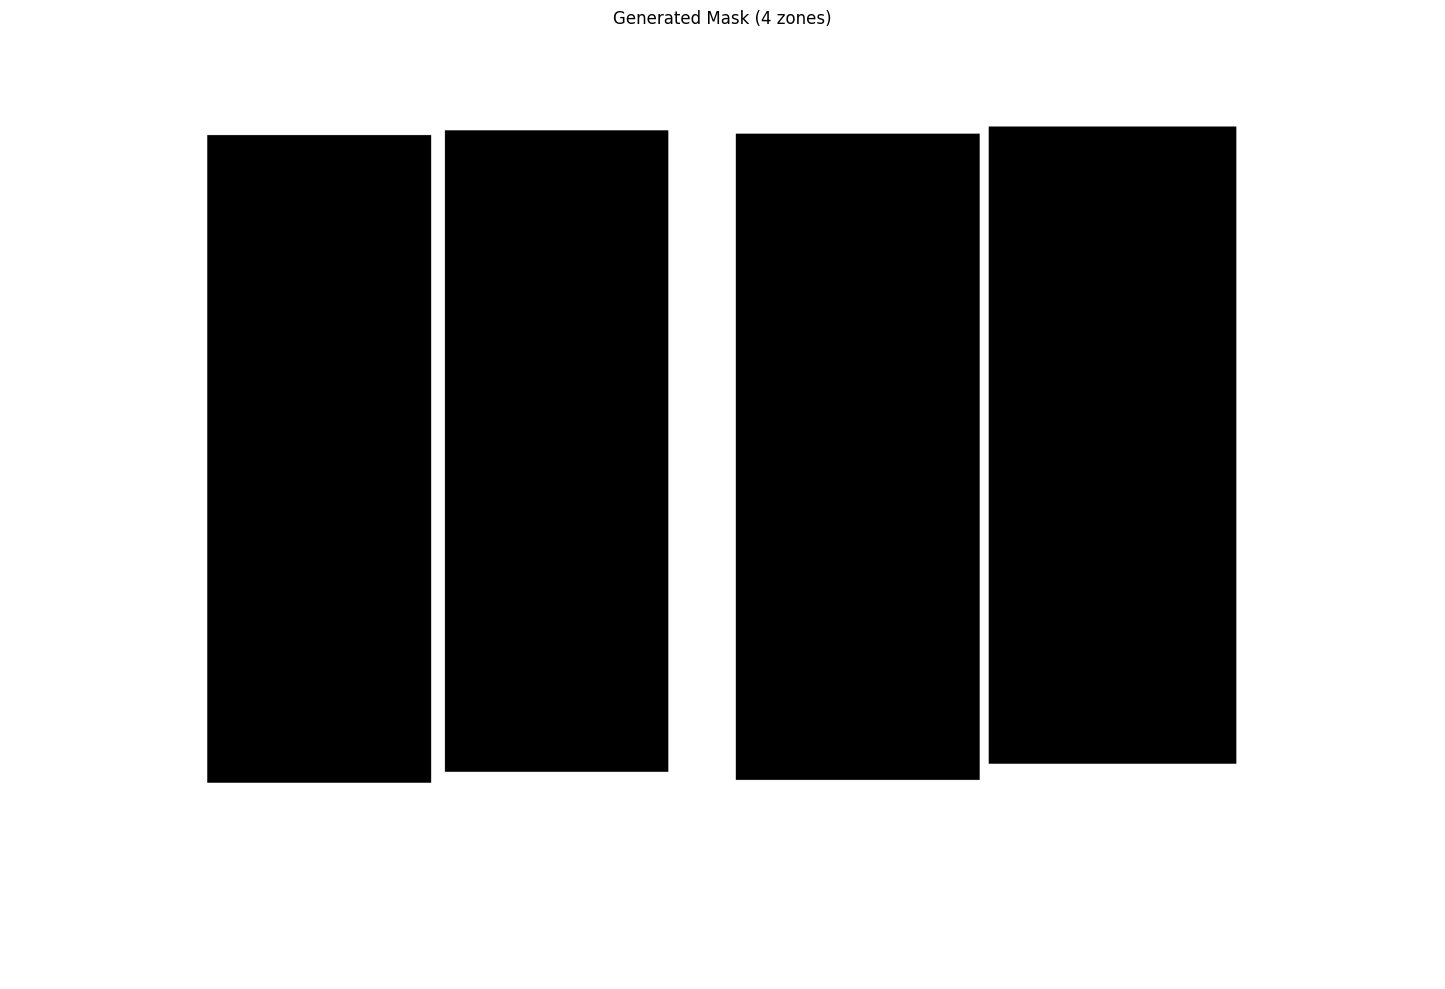

Mask saved to D:/Users/kju10/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR\tests\data_preprocessing\yolo_mask_zones.png


In [ ]:
boxes = results[0].boxes
mask_indices = boxes.cls == SEGMONTO_LIST.index("MainZone") 
zones = boxes.xyxy[mask_indices]
print(f"Total zones found: {len(zones)}") 
zones_np = zones.cpu().numpy()


for i, (x1, y1, x2, y2) in enumerate(zones_np):
    print(f"Drawing zone {i+1}: ({x1:.2f}, {y1:.2f}) to ({x2:.2f}, {y2:.2f})")
    pt1 = (int(x1), int(y1))
    pt2 = (int(x2), int(y2))
    cv2.rectangle(mask, pt1, pt2, color=0, thickness=-1)


plt.figure(figsize=(15, 10))
plt.imshow(mask, cmap='gray')
plt.title(f"Generated Mask ({len(zones_np)} zones)")
plt.axis('off')
plt.tight_layout()
plt.show()


output_path = os.path.join(PROJECT_ROOT, "tests", "data_preprocessing", "yolo_mask_zones.png")
cv2.imwrite(output_path, mask)
print(f"Mask saved to {output_path}")

In [21]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([4., 4., 2., 4., 4., 2., 2., 2., 2., 2., 2., 2., 2., 2.], device='cuda:0')
conf: tensor([0.9560, 0.9472, 0.9103, 0.9033, 0.9030, 0.8599, 0.8482, 0.8366, 0.8341, 0.7726, 0.5085, 0.4546, 0.3575, 0.3360], device='cuda:0')
data: tensor([[9.1568e+02, 2.0987e+02, 1.3841e+03, 1.5585e+03, 9.5598e-01, 4.0000e+00],
        [2.0598e+03, 2.0144e+02, 2.5794e+03, 1.5415e+03, 9.4718e-01, 4.0000e+00],
        [2.0628e+03, 1.9894e+02, 2.1950e+03, 2.8811e+02, 9.1026e-01, 2.0000e+00],
        [4.1550e+02, 2.1981e+02, 8.8510e+02, 1.5813e+03, 9.0333e-01, 4.0000e+00],
        [1.5278e+03, 2.1633e+02, 2.0395e+03, 1.5753e+03, 9.0302e-01, 4.0000e+00],
        [8.9180e+02, 2.7003e+02, 1.0299e+03, 3.6419e+02, 8.5988e-01, 2.0000e+00],
        [1.5672e+03, 1.0295e+03, 1.7244e+03, 1.1159e+03, 8.4822e-01, 2.0000e+00],
        [9.0719e+02, 1.2492e+03, 1.0339e+03, 1.3266e+03, 8.3662e-01, 2.0000e+00],
        [4.0244e+02, 1.0222e+03, 5.6136e+02, 1.12